Лабораторная работа #3

Настройка параметров SVM и его использоваиние для решения задачи классифиции спама

1) Параметры SVM и предварительная нормализация данных. 

Следующая функция 
будет полезна для построения границы решений. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt 

In [4]:
# Вспомогательная функция для построения границы решений 
def plotDecisionBoundary(model,X, y): 
     
    plt.scatter(X[:,0], X[:,1], c=y) 
 
    #  xx и yy - отложим по осям 
    x_min, x_max = X[:, 0].min() - 0.05, X[:, 0].max() + 0.05 
    y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05 
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.005), np.arange(y_min, 
y_max, 0.005)) 
     
    # Считаем выход модели 
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) 
    Z = Z.reshape(xx.shape) 
     
    # Строим границу решения 
    plt.contour(xx, yy, Z, [0.5], linewidths=1, colors='k') 



1.1. Линейный SVM для линейно разделимых классов.

Исходные данные - в файле data1.mat 

Для загрузки файлов с расширением mat воспользуемся функцией loadmat из пакета Scipy. 

1) Загрузите и постройте данные из файла data1.mat. Должна получиться 
примерно такая картинка. 

In [5]:
from scipy.io import loadmat #Загрузка файлов из формата .mat
from sklearn.svm import SVC, LinearSVC  #Включаем библиотеки SVC, LinearSVC

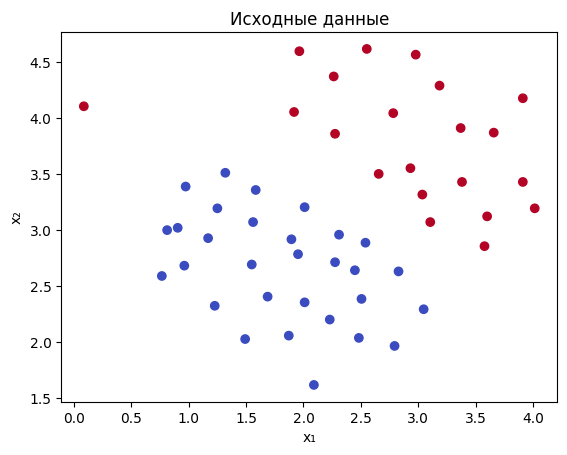

In [6]:
# 1. Линейный SVM 
data = loadmat('data1.mat') 

"""
Как Вы видите, набор данных X содержит два признака, y принимает значения 0,1 и 
отвечает за класс объекта. 
"""
X = data["X"] #Массив из двух столбцов X1, X2
y = data["y"].ravel() #Превращаем в вектор - метки классов (0/1)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Исходные данные")
plt.show()


Одинокий желтый круг слева представляет собой, по-видимому, выброс и дополнительную сложность для задачи классификации. 

Посмотрим, как с этим справится линейный SVM. 

1.0


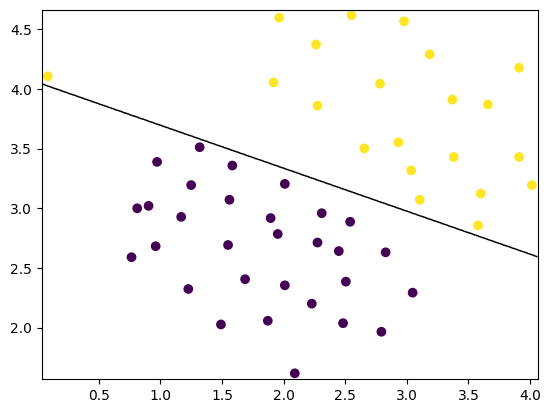

In [7]:
svcL = LinearSVC(C=2000) 
svcL.fit(X,y) 
result = svcL.score(X,y)

print(result)

"""
Построим границу решений и посмотрим, как проходит эта прямая по отношению к данным. 
"""
plotDecisionBoundary(svcL,X, y) 

2)  Посмотрите на качество решения Вашей задачи. Поменяйте значение параметра 
C с 1 на, например, 2000. Посмотрите, что поменялось и почему? Объясните 
результат. 

Напоминалка:
C - параметр регуляризации,управляет компромиссом между двумя целями : максимизацией ширины зазор (что соответствует минимизации ∥w∥ ) и минимизацией суммарной величины нарушений ξi

Большие значения C сильнее штрафуют ошибки классификации, вынуждая модель уменьшать количество нарушений, возможно? за счёт сужения зазора.
Малые значения C,напротив, допускают больше нарушений, но способствуют построению более широкой разделяющей полосы.

1.2 Нелинейный SVM для линейно неразделимых классов 

Исходные данные для второй задачи - в файле data2.mat 

3) Загрузите и визуализируйте этот набор данных. Он выглядит примерно так и 
требует нелинейного SVM. Почему? 

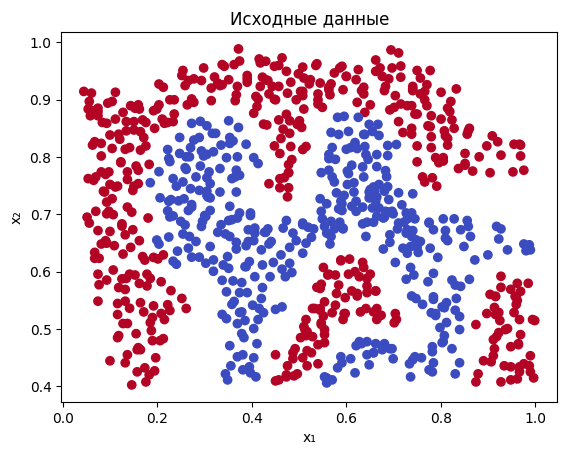

In [8]:
# 1. Линейный SVM 
data = loadmat('data2.mat') 

"""
Как Вы видите, набор данных X содержит два признака, y принимает значения 0,1 и 
отвечает за класс объекта. 
"""
X = data["X"] #Массив из двух столбцов X1, X2
y = data["y"].ravel() #Превращаем в вектор - метки классов (0/1)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Исходные данные")
plt.show()


Воспользуемся соответствующими функциями sklearn. 

In [9]:
svcN = SVC(kernel='rbf', C=100, gamma=10) 
svcN.fit(X,y) 
svcN.score(X,y)

0.9698725376593279

Здесь мы берем С=100 и RBF ядро с параметром 𝛾 = 10. Посмотрим на результат 
классификации. 

4) Постройте границу решений. Оцените точность работы классификатора. 
Попробуйте ее увеличить. За счет чего это можно сделать? 

Лучшие параметры: {'C': 10, 'gamma': 30}
Лучшая точность: 0.8466863825783035


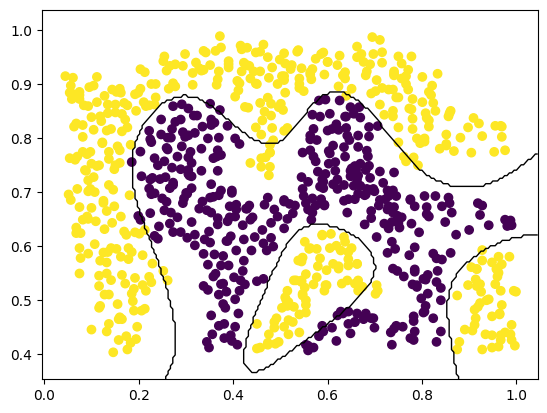

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.1, 1, 10, 30]
}

grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid.fit(X, y)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая точность:", grid.best_score_)

plotDecisionBoundary(svcN, X, y)

5) Зафиксируйте по очереди каждый из параметров и посмотрите, как меняется 
граница решений при изменении второго, нефиксированного, параметра.  

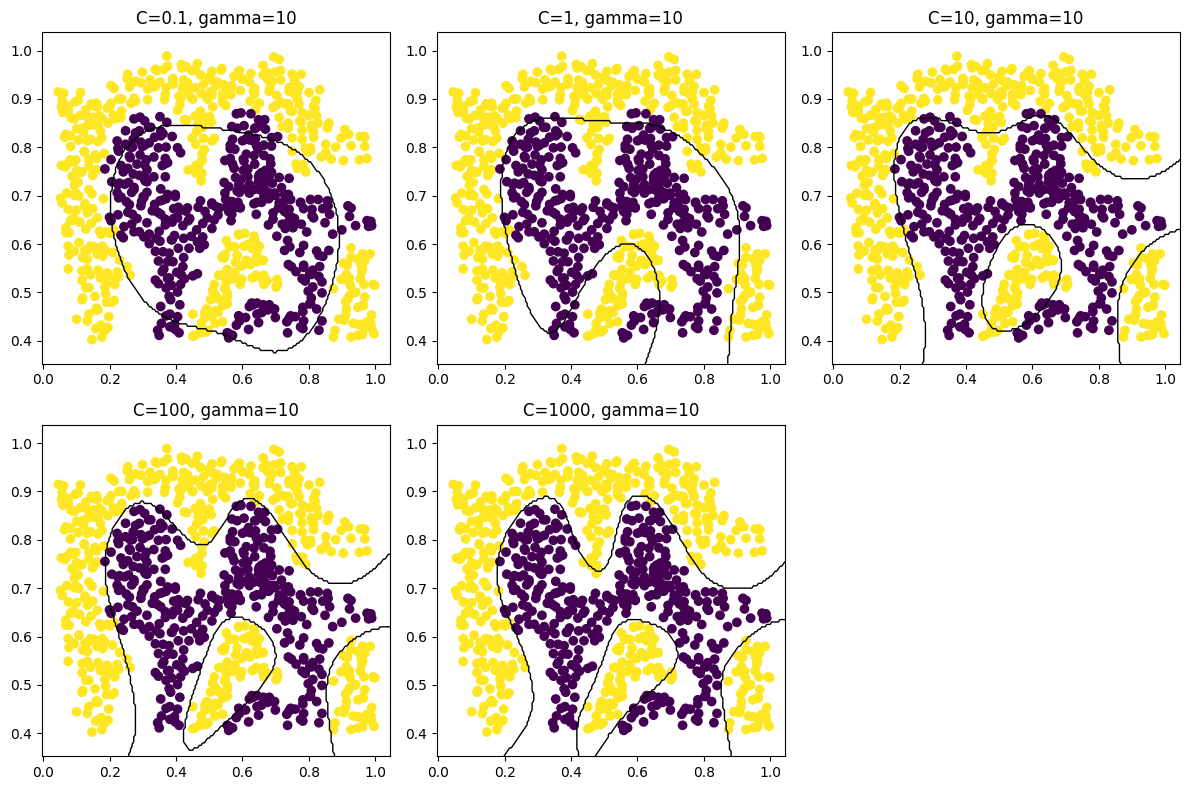

In [11]:
C_values = [0.1, 1, 10, 100, 1000]
gamma = 10  # фиксируем gamma

plt.figure(figsize=(12, 8))
for i, C in enumerate(C_values, 1):
    svc = SVC(kernel='rbf', C=C, gamma=gamma)
    svc.fit(X, y)
    plt.subplot(2, 3, i)
    plotDecisionBoundary(svc, X, y)
    plt.title(f"C={C}, gamma={gamma}")
plt.tight_layout()
plt.show()


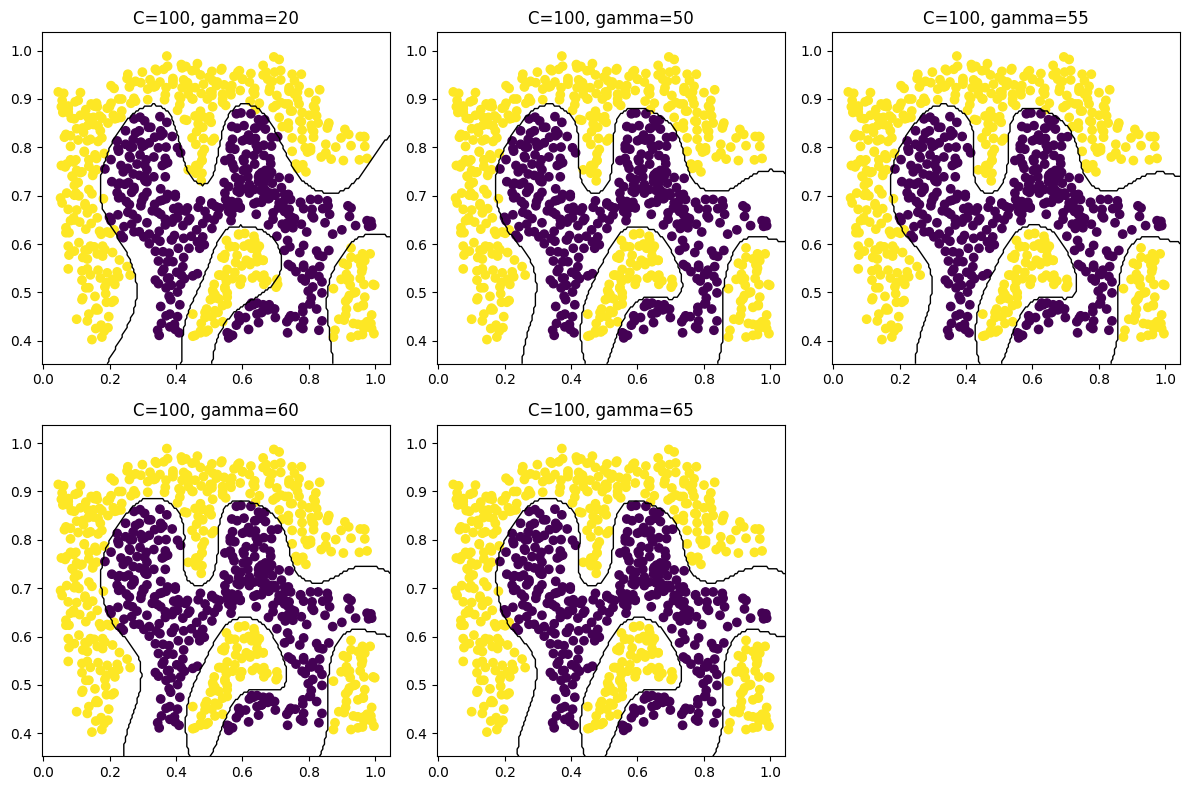

In [12]:
# gamma_values = [0.1, 1, 10, 50, 100]
gamma_values = [20, 50, 55, 60, 65]
C = 100  # фиксируем C

plt.figure(figsize=(12, 8))
for i, gamma in enumerate(gamma_values, 1):
    svc = SVC(kernel='rbf', C=C, gamma=gamma)
    svc.fit(X, y)
    plt.subplot(2, 3, i)
    plotDecisionBoundary(svc, X, y)
    plt.title(f"C={C}, gamma={gamma}")
plt.tight_layout()
plt.show()


6) Сделайте вывод, как каждый из параметров C и 𝜸 влияет на работу метода 
опорных векторов? 

Параметр γ управляет шириной гауссова колокола. 
Чем больше γ, тем более сложную границу может построить модель (рискуя переобучиться).
RBF-ядро соответствует отображению в бесконечномерное пространство.

При увеличении γ граница решений становится всё более сложной и чувствительной к данным.
При малом γ граница упрощается и теряет способность различать сложные формы классов.

1.3. Подбор параметров SVM для решения задачи нелинейной разделимости 

Исходные данные к третьей задаче - в файле data3.mat. Эта задача похожа на 
предыдущую, у нас снова линейно неразделимые два класса, но помимо обучающего 
набора данных, у нас еще есть и набор данных для проверки. 

In [13]:
#Загрузим данные
data = loadmat('data3.mat') 
X = data["X"] 
y = data["y"].ravel() 
X_test = data["Xval"] 
y_test = data["yval"].ravel() 

Для разделения классов будем использовать нелинейный SVM я ядром RBF.  

7) Подберите оптимальные параметры C и 𝜸 нелинейного классификатора c 
помощью решетчатого поиска и кроссвалидации по 5 папкам.  

Для этого Вам будет полезен [ссылка] и задача 4 в нем. 
[ссылка] - смотреть CV_GridSearch.ipynb 

In [14]:
import numpy as np
from sklearn.model_selection import cross_val_score
best_score = 0
for gamma in [1e-07, 1e-06, 1e-05, 1e-04, 1e-03, 0.01, 0.1, 1, 2, 3, 4, 10]:
    for C in [0.1, 1, 10, 50, 100, 200, 300, 400, 500, 540, 541, 549, 550, 560, 600, 700, 800]:

        # для каждой комбинации параметров,
        # обучаем SVC
        svm = SVC(gamma=gamma, C=C)

        # выполняем перекрестную проверку
        scores = cross_val_score(svm, X, y, cv=5)

        # вычисляем среднюю правильность перекрестной проверки
        score = np.mean(scores)

        # если получаем лучшее значение правильности, сохраняем значение и параметры
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

# заново строим модель на наборе, полученном в результате
# объединения обучающих и проверочных данных
svm = SVC(kernel='rbf', **best_parameters)
svm.fit(X, y)
test_score = svm.score(X_test, y_test)
print("Лучшее значение правильности на проверочном наборе: {:.3f}".format(best_score))
print("Наилучшие значения параметров: ", best_parameters)
print("Правильность на тестовом наборе с наилучшими параметрами: {:.3f}".format(test_score))

Лучшее значение правильности на проверочном наборе: 0.920
Наилучшие значения параметров:  {'C': 400, 'gamma': 2}
Правильность на тестовом наборе с наилучшими параметрами: 0.955


8) Подумайте, какая будет решетка параметров в этой задаче, как ее 
сформировать? 

9. Какова точность построенного Вами классификатора на тестовом наборе? 

10) Для лучшей найденной пары значений постройте границу решений 
соответствующей модели. 

1.4. Влияние предварительной нормализации данных на работу SVM 

Загрузим готовый набор данных Breast Cancer, содержащий 569 данных о 
злокачественных и доброкачественных опухолях. Каждая точка набора характеризуется 
30 признаками.  Мы собираемся решить задачу бинарной классификации и посмотреть, 
как сильно точность решения зависит от предварительной нормализации данных. 
Предварительно давайте часть данных оставим для проверки. Используем функцию 
train_test_split для разделения набора данных на обучающий и проверочный. По 
умолчанию данные будут разделены в соотношении 80%+20%. 

In [15]:
from sklearn.model_selection import train_test_split 
from sklearn.datasets import load_breast_cancer 
cancer = load_breast_cancer() 
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target) 

Обучите SVM классификатор на тренировочном наборе данных. Можно вызвать 
стандартный вариант SVM, пока никак не подбирая параметры метода 

In [16]:
svc = SVC() 
svc.fit(X_train, y_train) 
print("Правильность на обучающем наборе: {:.2f}".format(svc.score(X_train, y_train))) 
print("Правильность на тестовом наборе: {:.2f}".format(svc.score(X_test, y_test))) 

Правильность на обучающем наборе: 0.92
Правильность на тестовом наборе: 0.91


11) Оцените точность работы классификатора на тренировочном и проверочном 
наборе данных. Будут ли они близки? 

Скорее всего, Вы увидите, что точность на обоих наборах данных не сильно высока. Это 
во многом обусловлено сильно различающимися по величине признаками объектов.  

Точность до нормализации неплоха, но ещё не высокая. Возможно он видит в первую очередь большие признаки, а на маленькие признаки не замечает.

12) Постройте минимальное и максимальное значения каждого признака с тем, 
чтобы оценить, насколько одинаков диапазон их изменений. 

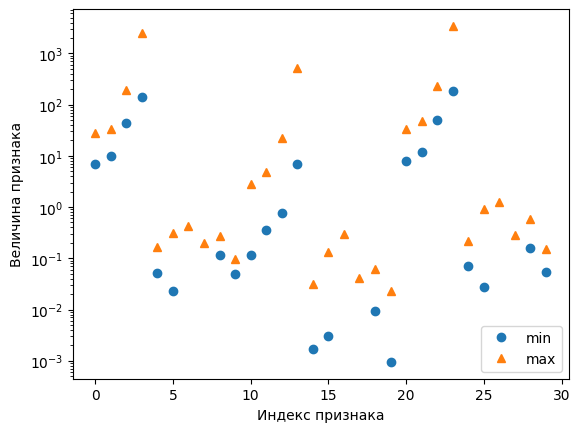

In [17]:
plt.plot(X_train.min(axis=0), 'o', label="min") 
plt.plot(X_train.max(axis=0), '^', label="max") 
plt.legend(loc=4) 
plt.xlabel("Индекс признака") 
plt.ylabel("Величина признака") 
plt.yscale("log")

Как видно, признаки отличаются очень сильно.  

Он показывает, что:
Для некоторых признаков значения лежат примерно 0.001 – 0.1
Для других — 10 – 100
А для некоторых → 1000 – 2000
То есть различия между признаками достигают 6 порядков (10⁶ раз).